In [42]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from skimage.metrics import structural_similarity, mean_squared_error

Домашнее задание

In [43]:
image_hw = cv2.imread('rs_ph.jpg')
image_gray_hw = cv2.cvtColor(image_hw, cv2.COLOR_BGR2GRAY) 

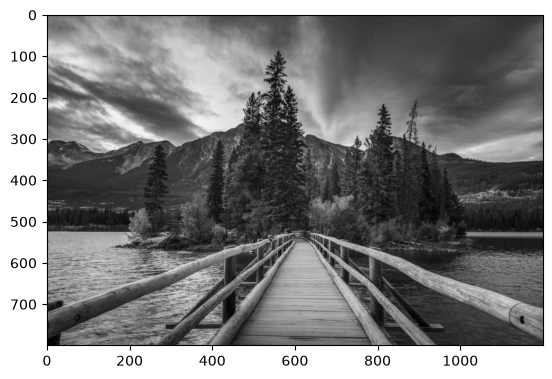

In [44]:
plt.imshow(image_gray_hw, cmap="gray")

In [45]:
# Задание 1
def add_gaussian_noise(img, mean=0, stddev=25):
    """Гауссов шум"""
    noise = np.zeros(img.shape, dtype=np.int16)
    cv2.randn(noise, mean, stddev)
    noisy = img.astype(np.int16) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

In [46]:
def add_uniform_noise(img, low=-50, high=50):
    """Равномерно распределённый шум"""
    noise = np.random.uniform(low, high, img.shape)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

In [47]:
np.random.seed(42)

img_gauss_noisy = add_gaussian_noise(image_gray_hw, mean=0, stddev=25)
img_uniform_noisy = add_uniform_noise(image_gray_hw, low=-50, high=50)

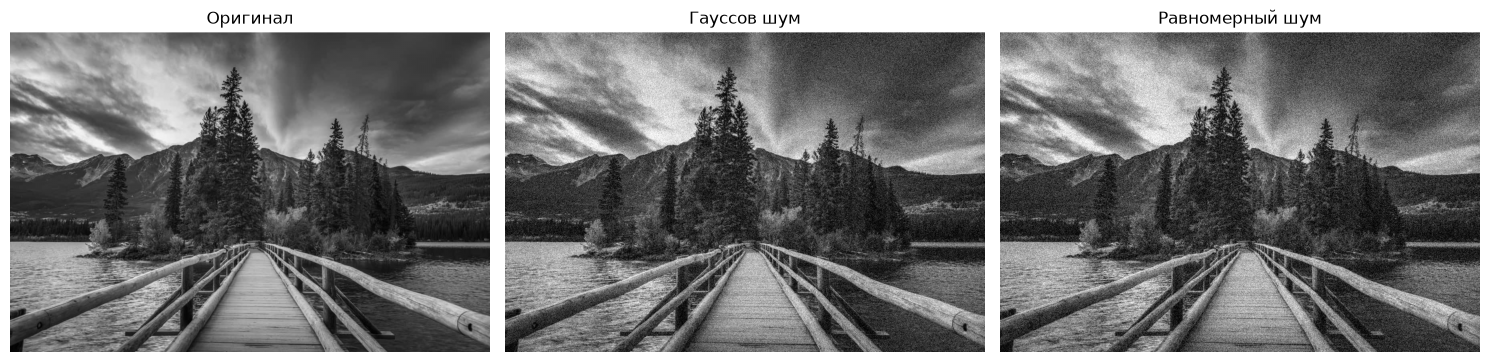

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_gray_hw, cmap="gray");      axes[0].set_title("Оригинал")
axes[1].imshow(img_gauss_noisy, cmap="gray");    axes[1].set_title("Гауссов шум")
axes[2].imshow(img_uniform_noisy, cmap="gray");  axes[2].set_title("Равномерный шум")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [49]:
mse_gauss_noisy  = mean_squared_error(image_gray_hw, img_gauss_noisy)
ssim_gauss_noisy = structural_similarity(image_gray_hw, img_gauss_noisy, full=True)[0]

mse_uniform_noisy  = mean_squared_error(image_gray_hw, img_uniform_noisy)
ssim_uniform_noisy = structural_similarity(image_gray_hw, img_uniform_noisy, full=True)[0]

print("Гауссов шум      - MSE: %.2f  SSIM: %.4f" % (mse_gauss_noisy, ssim_gauss_noisy))
print("Равномерный шум  - MSE: %.2f  SSIM: %.4f" % (mse_uniform_noisy, ssim_uniform_noisy))

Гауссов шум      - MSE: 598.60  SSIM: 0.3191
Равномерный шум  - MSE: 804.40  SSIM: 0.2693


In [50]:
# Задание 2
def apply_median(img, ksize=3):
    return cv2.medianBlur(img, ksize)

def apply_gaussian(img, ksize=(5, 5), sigma=0):
    return cv2.GaussianBlur(img, ksize, sigma)

def apply_bilateral(img, d=9, sigma_color=75, sigma_space=75):
    return cv2.bilateralFilter(img, d, sigma_color, sigma_space)

def apply_nlm(img, h=10, template_window=7, search_window=21):
    return cv2.fastNlMeansDenoising(img, None, h, template_window, search_window)

def evaluate(img_clean, img_denoised):
    mse  = mean_squared_error(img_clean, img_denoised)
    ssim = structural_similarity(img_clean, img_denoised, full=True)[0]
    return mse, ssim

In [51]:
param_grids = {
    "median":    [dict(ksize=k) for k in (3, 5, 7, 9)],
    "gaussian":  [dict(ksize=(k, k), sigma=s)
                  for k in (3, 5, 7, 9) for s in (0, 1, 2, 3)],
    "bilateral": [dict(d=d, sigma_color=sc, sigma_space=ss)
                  for d in (5, 9) for sc in (30, 75, 150) for ss in (30, 75, 150)],
    "nlm":       [dict(h=h, template_window=tw, search_window=sw)
                  for h in (5, 10, 15, 20, 25)
                  for tw in (5, 7) for sw in (15, 21)],
}

filters = {
    "median":    apply_median,
    "gaussian":  apply_gaussian,
    "bilateral": apply_bilateral,
    "nlm":       apply_nlm,
}

In [52]:
def run_benchmark(noisy_img, label):
    results = []   
    for fname, fn in filters.items():
        for params in param_grids[fname]:
            try:
                denoised = fn(noisy_img, **params)
            except cv2.error:
                continue
            mse, ssim = evaluate(image_gray_hw, denoised)
            results.append((fname, params, mse, ssim, denoised))

    print(f"\n==================== Шум: {label} ====================")
    
    df = pd.DataFrame(results, columns=['Фильтр', 'Параметры', 'MSE', 'SSIM', 'Img'])
    df = df.drop(columns=['Img'])
    df = df.sort_values(by='MSE').reset_index(drop=True)
    
    print("ТОП-10 лучших результатов по MSE:")
    display(df.head(10)) 
    
    best_mse  = min(results, key=lambda r: r[2])
    best_ssim = max(results, key=lambda r: r[3])
    print("\nЛучший по MSE :", best_mse[0],  best_mse[1],
          f"-> MSE={best_mse[2]:.2f}, SSIM={best_mse[3]:.4f}")
    print("Лучший по SSIM:", best_ssim[0], best_ssim[1],
          f"-> MSE={best_ssim[2]:.2f}, SSIM={best_ssim[3]:.4f}")
    return results, best_mse, best_ssim

In [53]:
results_gauss, best_gauss_mse, best_gauss_ssim = run_benchmark(img_gauss_noisy, "Гауссов")
results_uniform, best_uniform_mse, best_uniform_ssim = run_benchmark(img_uniform_noisy, "Равномерный")


==================== Шум: Гауссов ====================
ТОП-10 лучших результатов по MSE:


,Фильтр,Параметры,MSE,SSIM
0,nlm,"{'h': 25, 'template_window': 5, 'search_window...",82.600418,0.765079
1,nlm,"{'h': 25, 'template_window': 5, 'search_window...",87.065237,0.765778
2,nlm,"{'h': 25, 'template_window': 7, 'search_window...",88.646178,0.762387
3,nlm,"{'h': 20, 'template_window': 5, 'search_window...",91.859204,0.744181
4,bilateral,"{'d': 5, 'sigma_color': 75, 'sigma_space': 30}",94.349807,0.706172
5,bilateral,"{'d': 5, 'sigma_color': 75, 'sigma_space': 75}",94.353792,0.706173
6,bilateral,"{'d': 5, 'sigma_color': 75, 'sigma_space': 150}",94.355355,0.706173
7,nlm,"{'h': 20, 'template_window': 7, 'search_window...",95.642523,0.760677
8,nlm,"{'h': 25, 'template_window': 7, 'search_window...",97.218243,0.755274
9,nlm,"{'h': 20, 'template_window': 5, 'search_window...",101.909757,0.716919



Лучший по MSE : nlm {'h': 25, 'template_window': 5, 'search_window': 15} -> MSE=82.60, SSIM=0.7651
Лучший по SSIM: nlm {'h': 25, 'template_window': 5, 'search_window': 21} -> MSE=87.07, SSIM=0.7658

==================== Шум: Равномерный ====================
ТОП-10 лучших результатов по MSE:


,Фильтр,Параметры,MSE,SSIM
0,nlm,"{'h': 25, 'template_window': 5, 'search_window...",100.585357,0.722293
1,nlm,"{'h': 25, 'template_window': 5, 'search_window...",102.629353,0.706816
2,nlm,"{'h': 25, 'template_window': 7, 'search_window...",103.273706,0.729443
3,nlm,"{'h': 25, 'template_window': 7, 'search_window...",105.574703,0.737635
4,bilateral,"{'d': 5, 'sigma_color': 150, 'sigma_space': 30}",123.353548,0.663218
5,bilateral,"{'d': 5, 'sigma_color': 150, 'sigma_space': 75}",123.370338,0.663192
6,bilateral,"{'d': 5, 'sigma_color': 150, 'sigma_space': 150}",123.371851,0.663189
7,gaussian,"{'ksize': (7, 7), 'sigma': 1}",124.527224,0.675099
8,gaussian,"{'ksize': (9, 9), 'sigma': 1}",124.527224,0.675099
9,gaussian,"{'ksize': (5, 5), 'sigma': 0}",124.965082,0.681561



Лучший по MSE : nlm {'h': 25, 'template_window': 5, 'search_window': 21} -> MSE=100.59, SSIM=0.7223
Лучший по SSIM: nlm {'h': 25, 'template_window': 7, 'search_window': 21} -> MSE=105.57, SSIM=0.7376


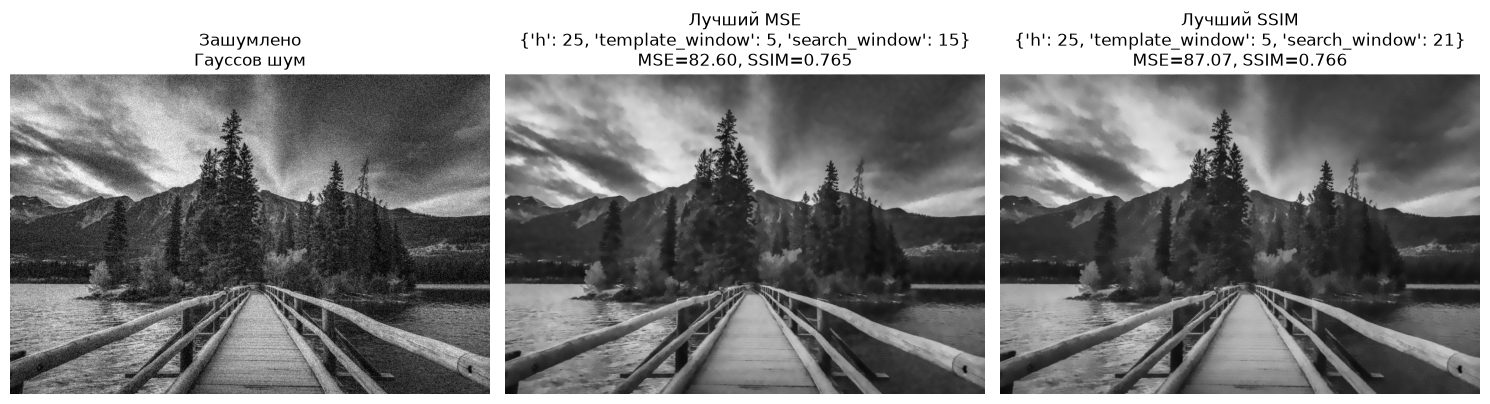

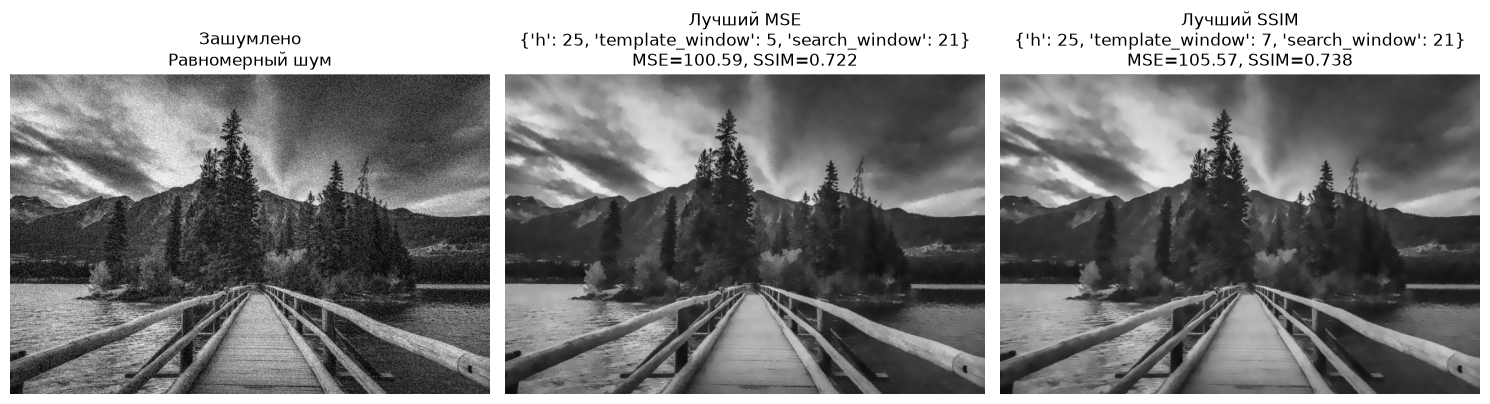

In [54]:
def show_best(noisy, best_mse, best_ssim, title):
    _, p_mse,  mse_mse,  ssim_mse,  img_mse  = best_mse
    _, p_ssim, mse_ssim, ssim_ssim, img_ssim = best_ssim

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(noisy, cmap="gray")
    axes[0].set_title(f"Зашумлено\n{title}"); axes[0].axis("off")

    axes[1].imshow(img_mse, cmap="gray")
    axes[1].set_title(f"Лучший MSE\n{p_mse}\nMSE={mse_mse:.2f}, SSIM={ssim_mse:.3f}")
    axes[1].axis("off")

    axes[2].imshow(img_ssim, cmap="gray")
    axes[2].set_title(f"Лучший SSIM\n{p_ssim}\nMSE={mse_ssim:.2f}, SSIM={ssim_ssim:.3f}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


show_best(img_gauss_noisy, best_gauss_mse, best_gauss_ssim, "Гауссов шум")
show_best(img_uniform_noisy, best_uniform_mse, best_uniform_ssim, "Равномерный шум")

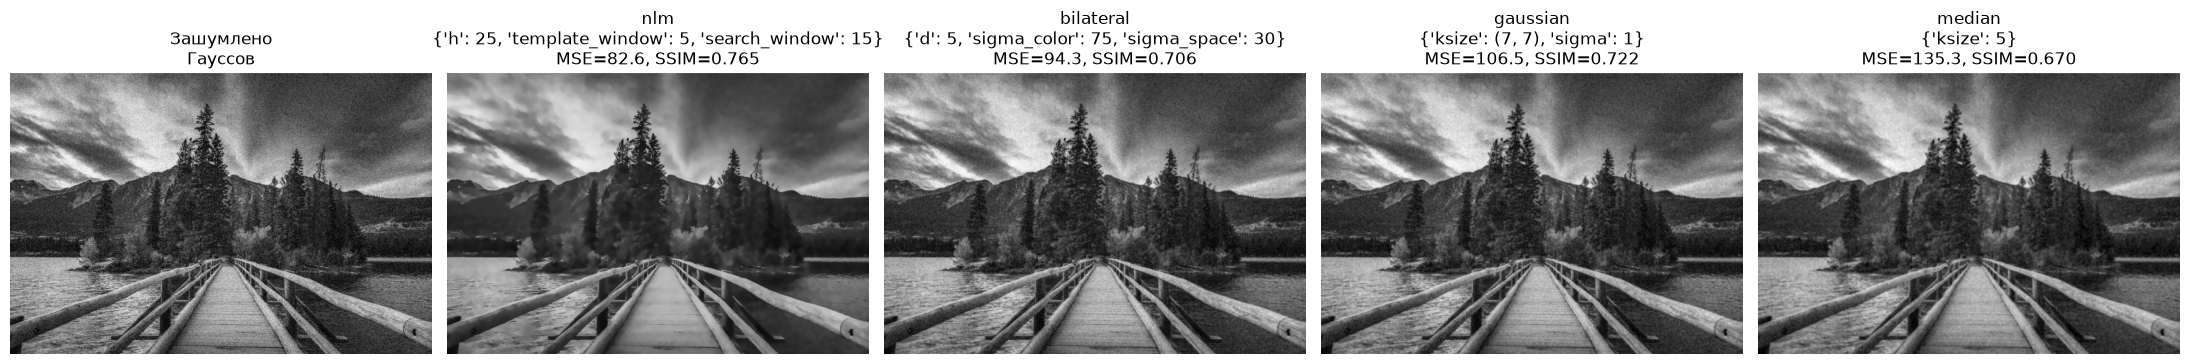

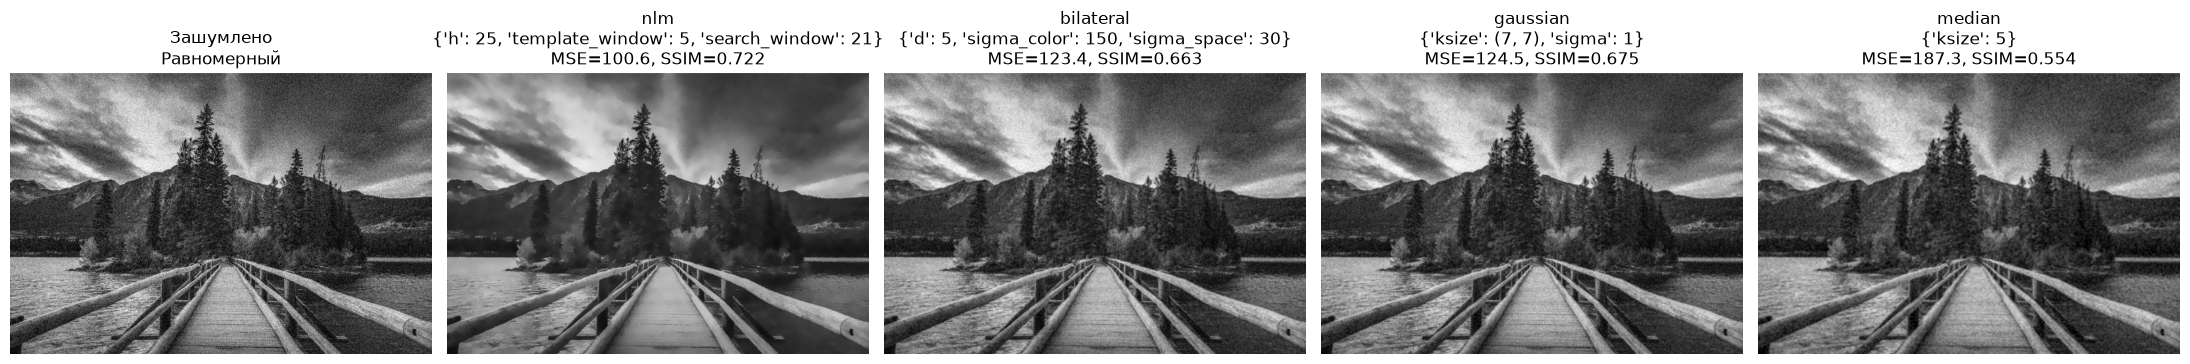

In [55]:
def top_per_filter(results):
    out = {}
    for fname, params, mse, ssim, img in sorted(results, key=lambda r: r[2]):
        if fname not in out:
            out[fname] = (params, mse, ssim, img)
    return out


for label, results, noisy in [("Гауссов", results_gauss, img_gauss_noisy),
                              ("Равномерный", results_uniform, img_uniform_noisy)]:
    top = top_per_filter(results)
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    axes[0].imshow(noisy, cmap="gray")
    axes[0].set_title(f"Зашумлено\n{label}")
    axes[0].axis("off")

    for i, (fname, (params, mse, ssim, img)) in enumerate(top.items(), start=1):
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f"{fname}\n{params}\nMSE={mse:.1f}, SSIM={ssim:.3f}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

In [56]:
# Задание 3
print("=" * 60)
print("ВЫВОДЫ")
print("=" * 60)

print("\n[Гауссов шум]")
print("  Лучший MSE  :", best_gauss_mse[0],  best_gauss_mse[1],
      f"-> MSE={best_gauss_mse[2]:.2f}, SSIM={best_gauss_mse[3]:.4f}")
print("  Лучший SSIM :", best_gauss_ssim[0], best_gauss_ssim[1],
      f"-> MSE={best_gauss_ssim[2]:.2f}, SSIM={best_gauss_ssim[3]:.4f}")

print("\n[Равномерный шум]")
print("  Лучший MSE  :", best_uniform_mse[0],  best_uniform_mse[1],
      f"-> MSE={best_uniform_mse[2]:.2f}, SSIM={best_uniform_mse[3]:.4f}")
print("  Лучший SSIM :", best_uniform_ssim[0], best_uniform_ssim[1],
      f"-> MSE={best_uniform_ssim[2]:.2f}, SSIM={best_uniform_ssim[3]:.4f}")

ВЫВОДЫ

[Гауссов шум]
  Лучший MSE  : nlm {'h': 25, 'template_window': 5, 'search_window': 15} -> MSE=82.60, SSIM=0.7651
  Лучший SSIM : nlm {'h': 25, 'template_window': 5, 'search_window': 21} -> MSE=87.07, SSIM=0.7658

[Равномерный шум]
  Лучший MSE  : nlm {'h': 25, 'template_window': 5, 'search_window': 21} -> MSE=100.59, SSIM=0.7223
  Лучший SSIM : nlm {'h': 25, 'template_window': 7, 'search_window': 21} -> MSE=105.57, SSIM=0.7376
